# 08 - Graph transformers & positional encodings

Message passing is **local**: information crawls one hop per layer, which causes the
over-squashing we saw in notebook 06. **Graph transformers** take the opposite stance -
let **every node attend to every other node in a single layer**, exactly like a
transformer over tokens. That kills the distance bottleneck.

But there's a catch. A plain transformer is **permutation-invariant and structure-blind**:
fed only node features, it has no idea how the nodes are connected. The fix is
**positional / structural encodings (PE/SE)** - extra features that tell each node
*where it sits* in the graph. This notebook builds two encodings by hand and then uses a
**GraphGPS** hybrid (local message passing **+** global attention) to crush a long-range
task that message passing alone cannot.

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))   # make utils/ importable from notebooks/

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
torch.manual_seed(0); np.random.seed(0)

from utils import graphs as G     # synthetic graph generators (known ground truth)
from utils import models as M     # the model zoo (MLP, GCN, SAGE, GAT, GIN, GPS, ...)
from utils import training as T    # train/eval loops + metrics
from utils import plotting as P    # graph drawing, curves, comparisons


## Structural encodings, by hand

Two standard encodings, computed here with plain dense linear algebra (no special
dependencies):

- **Random-Walk SE (RWSE)**: for each node, the probability of returning to itself after
  `k` steps of a random walk, for `k = 1..K`. It's a fingerprint of *local structure*
  (a node in a triangle returns sooner than a node on a path).
- **Laplacian PE (LapPE)**: the lowest non-trivial eigenvectors of the normalised graph
  Laplacian - a graph-aware analogue of sin/cos positional encodings.

In [2]:
def rwse(data, K=4):
    n = data.num_nodes
    A = torch.zeros(n, n); A[data.edge_index[0], data.edge_index[1]] = 1.0
    Dinv = torch.diag(A.sum(1).clamp_min(1).pow(-1))
    P_ = Dinv @ A                                  # random-walk transition matrix
    out, Pk = [], torch.eye(n)
    for _ in range(K):
        Pk = Pk @ P_
        out.append(torch.diagonal(Pk).unsqueeze(1))  # return probability
    return torch.cat(out, dim=1)

def lap_pe(data, k=4):
    n = data.num_nodes
    A = torch.zeros(n, n); A[data.edge_index[0], data.edge_index[1]] = 1.0
    Dinv2 = torch.diag(A.sum(1).clamp_min(1).pow(-0.5))
    L = torch.eye(n) - Dinv2 @ A @ Dinv2           # normalised Laplacian
    evals, evecs = torch.linalg.eigh(L)
    return evecs[:, 1:k+1]                          # skip the trivial first eigenvector

# RWSE separates structural roles that raw (noise) features cannot.
role, _ = G.make_structural_role(n_gadgets=40, seed=0)
se = rwse(role, K=4)
tri = role.y == 1
print("mean RWSE (return prob) by structural role, k=1..4:")
print("  triangle nodes:", se[tri].mean(0).round(decimals=3).tolist())
print("  path nodes    :", se[~tri].mean(0).round(decimals=3).tolist())
print("-> identical noise features, but RWSE tells the roles apart.")

mean RWSE (return prob) by structural role, k=1..4:
  triangle nodes: [0.0, 0.39100000262260437, 0.12700000405311584, 0.23499999940395355]
  path nodes    : [0.0, 0.503000020980835, 0.0, 0.35600000619888306]
-> identical noise features, but RWSE tells the roles apart.


## GraphGPS vs GIN on a long-range task

Back to **RingTransfer** from notebook 06: the answer is `ring_size/2` hops from the
source. A shallow message-passing model can't reach it. A **GraphGPS** model (each layer
= local GIN **+** global multihead attention) lets the source attend directly to the
target - distance becomes irrelevant. We give both models the **same depth** and the
same RWSE features, and grow the ring.

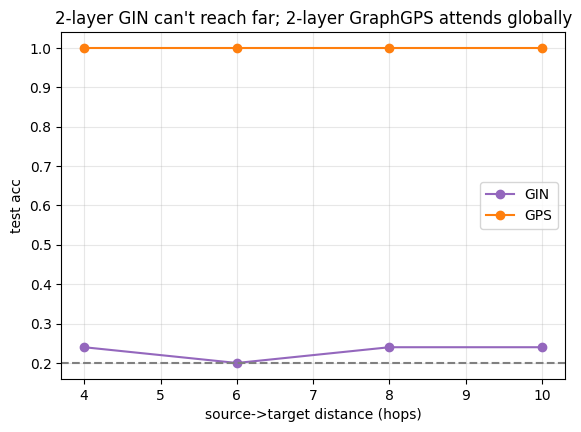

,GIN,GPS
d=4,0.24,1.0
d=6,0.20,1.0
d=8,0.24,1.0
d=10,0.24,1.0


In [3]:
def add_rwse(graphs, K=4):
    out = []
    for g in graphs:
        g = g.clone()
        g.x = torch.cat([g.x, rwse(g, K)], dim=1)
        out.append(g)
    return out

ring_sizes = [8, 12, 16, 20]
series = {"GIN": [], "GPS": []}
for rs in ring_sizes:
    graphs, _ = G.make_ring_transfer(num_graphs=500, ring_size=rs, num_classes=5, seed=0)
    graphs = add_rwse(graphs, K=4)
    loaders = T.make_graph_loaders(graphs, batch_size=64, seed=0)
    ind = graphs[0].num_features
    T.set_seed(0)
    gin = M.GraphGNN(ind, 32, 5, conv="gin", n_layers=2, pool="source")
    series["GIN"].append(T.train_graph(gin, loaders, epochs=40)["test_metric"])
    T.set_seed(0)
    gps = M.GPSModel(ind, 32, 5, n_layers=2, heads=4, pool="source")
    series["GPS"].append(T.train_graph(gps, loaders, epochs=40)["test_metric"])

P.plot_sweep([r//2 for r in ring_sizes], series, xlabel="source->target distance (hops)",
             ylabel="test acc", title="2-layer GIN can't reach far; 2-layer GraphGPS attends globally")
plt.axhline(0.2, ls="--", color="gray"); plt.show()
pd.DataFrame(series, index=[f"d={r//2}" for r in ring_sizes]).round(3)

## The current landscape (2023-2025)

Graph transformers are a fast-moving area; the ideas worth knowing:

- **GraphGPS** (Rampasek et al., 2022): the recipe we used - *local MPNN + global
  attention + PE/SE*, modular and strong across benchmarks.
- **Exphormer**: sparse attention (expander graphs + virtual nodes) to make global
  attention scale to large graphs instead of costing $O(N^2)$.
- **Graph-Mamba / state-space GNNs** (2024): replace quadratic attention with a linear
  **selective state-space** scan over nodes - long-range context at near-linear cost.
- **Virtual nodes**: a single node connected to everything - a poor-man's global channel
  that already mitigates over-squashing cheaply.

**When to reach for a graph transformer**

- (+) **Long-range dependencies** that local message passing squashes (the demo above).
- (+) Small-to-medium graphs (molecules, where SOTA is GPS-style) and tasks where global
  context matters.
- (!) Cost: full attention is $O(N^2)$ - for big graphs use sparse/linear variants. On
  short-range, homophilous problems a plain GCN/SAGE is cheaper and just as good.

Next: **link prediction** - predicting the *edges* themselves.